# Breast Cancer Classification with Machine Learning

This notebook builds and evaluates machine learning models to classify breast tumours as **benign** or **malignant** using the Breast Cancer Wisconsin dataset from scikit-learn.

The workflow follows these steps:
1. Data loading and exploration
2. Preprocessing and feature scaling
3. Model training (SVM, Logistic Regression, Random Forest)
4. Evaluation and model comparison




## 1. Importing Libraries

In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer


## 2. Loading the Dataset

The **Breast Cancer Wisconsin dataset** contains 569 patient samples and 30 numerical features computed from digitised images of breast mass cell nuclei. Each sample is labelled as either malignant or benign.

In [4]:
# Load the built-in Breast Cancer Wisconsin dataset from scikit-learn
# This dataset contains features computed from digitized images of breast mass cell nuclei
cancer = load_breast_cancer()

# Print a detailed description of the dataset
# This includes background information, feature explanations, and class labels
print(cancer.DESCR)


.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## 3. Creating the DataFrame

We convert the dataset into a Pandas DataFrame for easier exploration and manipulation. Each row represents a patient sample and each column represents a measured feature.

In [6]:
# Create a Pandas DataFrame
# Rows represent individual patient samples
# Columns represent the measured features extracted from cell nuclei images
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['diagnosis'] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 4. Target Variable Encoding

The original scikit-learn encoding uses `0 = malignant` and `1 = benign`. We invert this so that `1 = malignant` (positive class) and `0 = benign`, which is the standard convention in medical classification — making the disease the positive case.

In [7]:
# Create a binary target variable for model training
# Original scikit-learn encoding:
#   0 = malignant
#   1 = benign
# We invert this so that:
#   1 = malignant (positive class)
#   0 = benign
df['diagnosis'] = (cancer.target == 0).astype(int)

# Check and validate dataset structure
print("Dataset loaded and target variable created successfully.")
print(f"Dataset shape (rows, columns): {df.shape}")

# Validate target encoding
print("\nTarget variable validation:")
print("Original target unique values (0=malignant, 1=benign):", np.unique(cancer.target))
print("New 'diagnosis' unique values (1=malignant, 0=benign):", np.unique(df['diagnosis']))
print("\nClass distribution in 'diagnosis':")
print(df['diagnosis'].value_counts())


Dataset loaded and target variable created successfully.
Dataset shape (rows, columns): (569, 31)

Target variable validation:
Original target unique values (0=malignant, 1=benign): [0 1]
New 'diagnosis' unique values (1=malignant, 0=benign): [0 1]

Class distribution in 'diagnosis':
diagnosis
0    357
1    212
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

Before training any model, we explore the dataset to understand its structure, data types, missing values, and statistical distributions.



### 5.1 Data Types

In [8]:
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


### 5.2 Missing Values

We check for missing values across all columns. Missing data can severely impact model performance and must be handled before training.

In [9]:
# Checking for missing values
print("\nDataset info (columns, data types, non-null counts):")
df.info()


Dataset info (columns, data types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               5

### 5.3 Statistical Summary

A statistical summary of all numerical features including mean, standard deviation, min, and max values. This helps identify features with very different scales, which is important for models sensitive to feature magnitude such as SVM.

In [6]:
# Statistical summary of numerical features
print("\nStatistical summary of numerical features:")
print(df.describe())


Statistical summary of numerical features:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380      

### 5.4 Feature Distributions by Diagnosis

Histograms of all 30 features separated by diagnosis class. Features where the two distributions are clearly separated (little overlap) are likely to be strong predictors for the model.

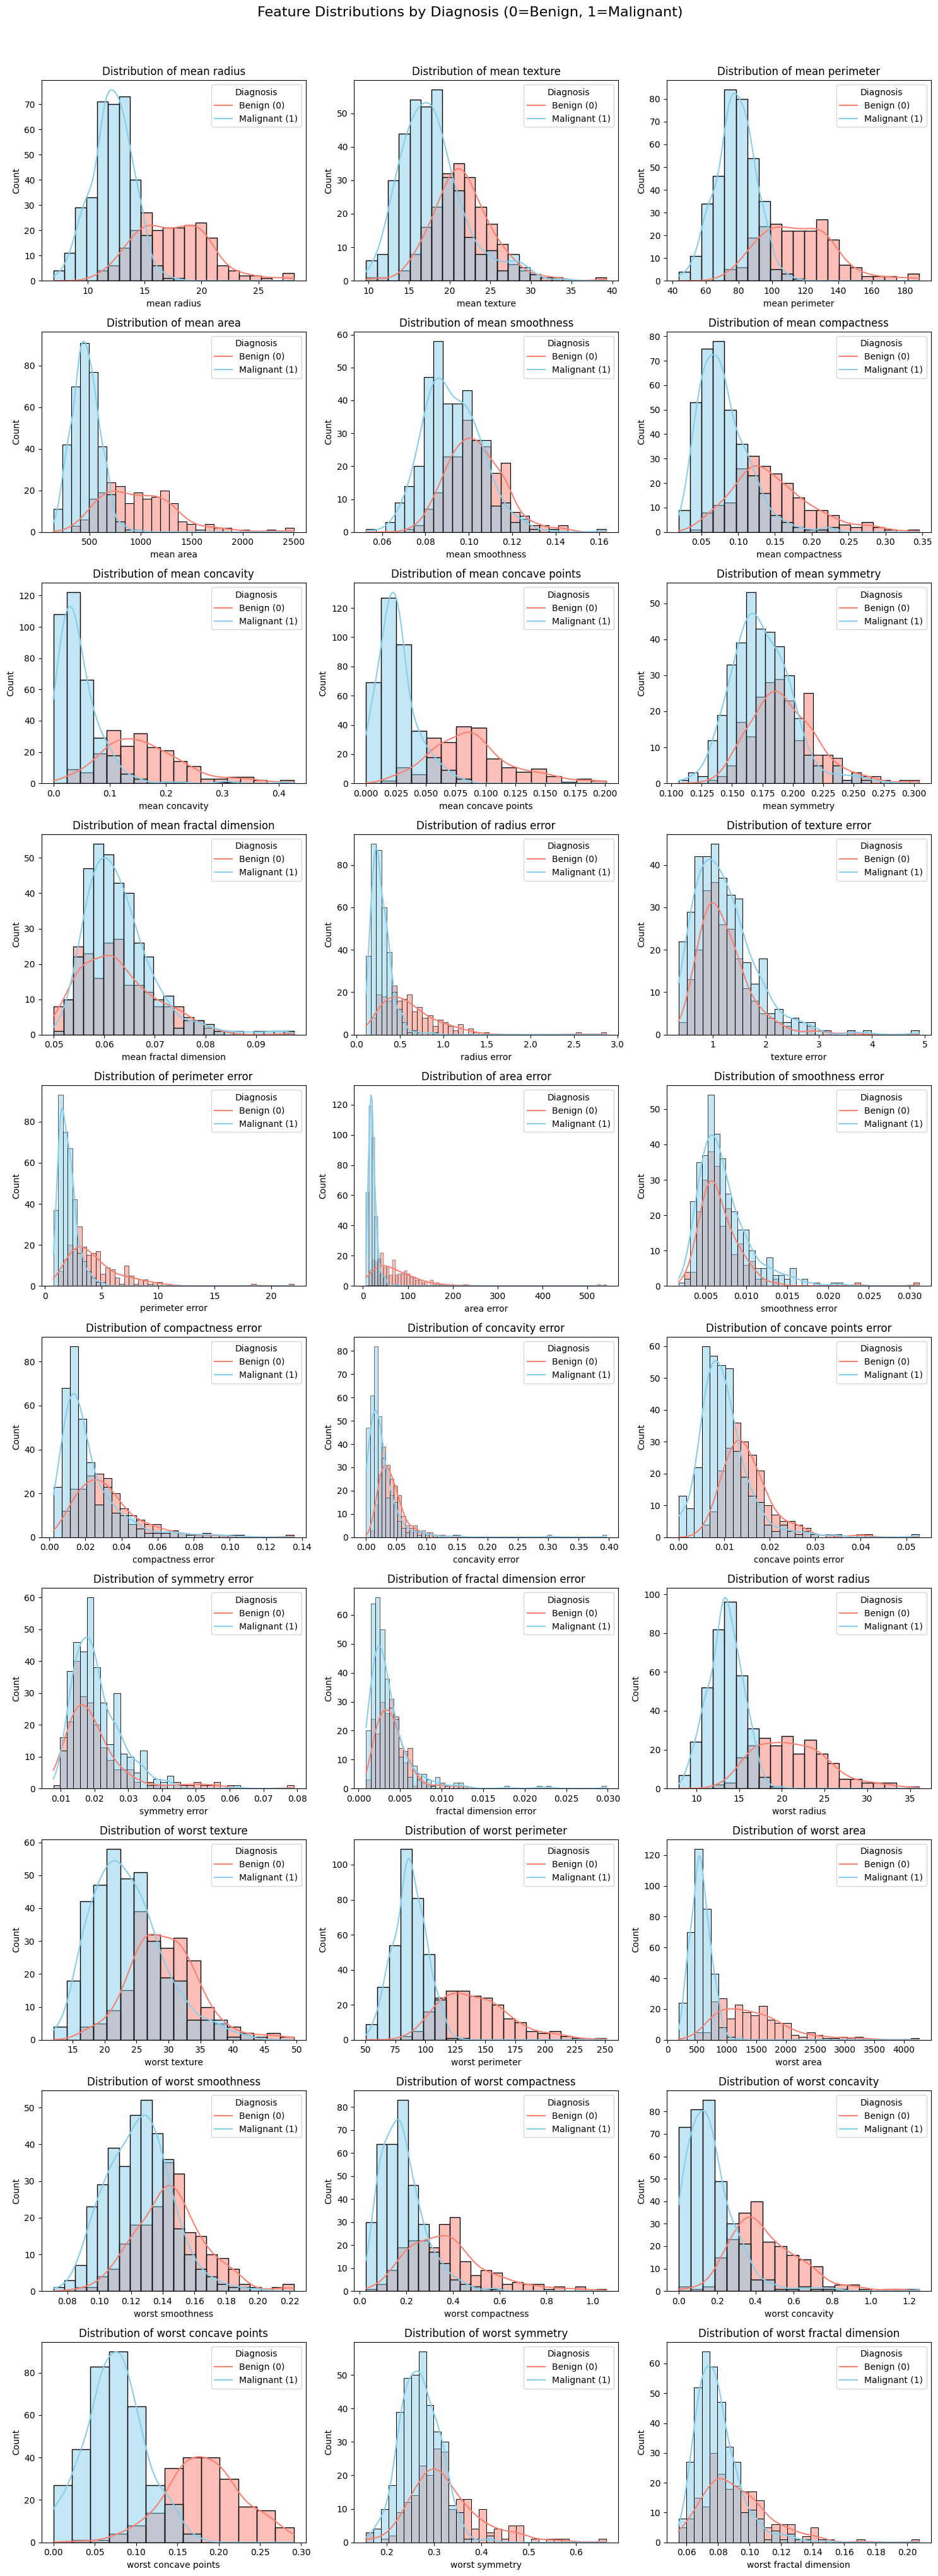

In [10]:
# # Plot histograms for a all features
# Remove target feature, 'diagnosis' to get only numerical features
numerical_features = df.drop('diagnosis', axis=1).columns

# Create histograms for all numerical features, separated by diagnosis
# Determine number of rows and columns for subplots
n_features = len(numerical_features)
n_cols = 3
# Ceiling Division: the formula (n_features + n_cols - 1) // n_cols ensures that we have enough subplot rows to display all
# features in a grid of n_cols columns, even if the total number of features isn’t divisible evenly.
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten to easily iterate over axes

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, ax=axes[i], palette={0: 'skyblue', 1: 'salmon'})
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].legend(title='Diagnosis', labels=['Benign (0)', 'Malignant (1)'])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Feature Distributions by Diagnosis (0=Benign, 1=Malignant)", fontsize=16, y=1.02)
plt.show()

## 6. Preprocessing

### 6.1 Defining Features and Target

We separate the dataset into:
- **X** — the feature matrix (30 input features)
- **Y** — the target vector (0 = Benign, 1 = Malignant)

In [13]:
X = df.drop('diagnosis', axis=1).values
Y = df['diagnosis'].values

### 6.2 Train / Test Split

We split the data into **75% training** and **25% test** sets. The training set is used to fit the models and the test set is used to evaluate performance on unseen data. `random_state=0` ensures the split is reproducible.

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.75,test_size=0.25,random_state=0)


### 6.3 Feature Scaling

We apply **StandardScaler** to normalise all features to have a mean of 0 and a standard deviation of 1. This is essential for distance-based and margin-based models like SVM and Logistic Regression, which are sensitive to features on different scales.

> **Important:** The scaler is fitted on the training data only (`fit_transform`) and then applied to the test data (`transform`) to prevent data leakage.

In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 7. Model Training & Evaluation

We train and evaluate three classification models. Each model is assessed using accuracy, a confusion matrix, and a full classification report including precision, recall, and F1-score.

> In a medical classification context, **Recall** is the most critical metric — it measures how many actual malignant cases were correctly identified. A missed malignant case (false negative) carries far greater risk than a false alarm (false positive).

---

### 7.1 Support Vector Machine (SVM)

SVM finds the optimal hyperplane that maximises the margin between classes. With a linear kernel, it performs well on high-dimensional data like this dataset (30 features) and is robust on smaller datasets.

SVM Accuracy: 97.20%


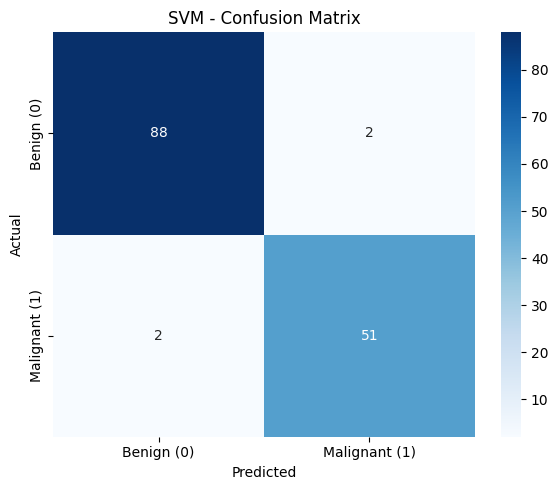

SVM - Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.98      0.98      0.98        90
Malignant (1)       0.96      0.96      0.96        53

     accuracy                           0.97       143
    macro avg       0.97      0.97      0.97       143
 weighted avg       0.97      0.97      0.97       143



In [29]:
# =============================================================
# SUPPORT VECTOR MACHINE (SVM) CLASSIFIER
# =============================================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize SVM model with a linear kernel
# kernel='linear' works well for high-dimensional data like this dataset (30 features)
# random_state=0 ensures reproducibility
classifier = SVC(kernel='linear', random_state=0)

# Train the model on the scaled training data
classifier.fit(X_train, Y_train)

# Predict on the test set
Y_pred = classifier.predict(X_test)

# ── Accuracy ──────────────────────────────────────────────────
accuracy = accuracy_score(Y_test, Y_pred)
print(f"SVM Accuracy: {accuracy * 100:.2f}%")

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('SVM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── Classification Report ─────────────────────────────────────
print("SVM - Classification Report:")
print(classification_report(Y_test, Y_pred,
      target_names=['Benign (0)', 'Malignant (1)']))

### 7.2 Logistic Regression

Logistic Regression is a strong and interpretable baseline for binary classification. It models the probability of a sample belonging to the positive class (malignant) and is well-suited for linearly separable data.

Logistic Regression Accuracy: 95.80%


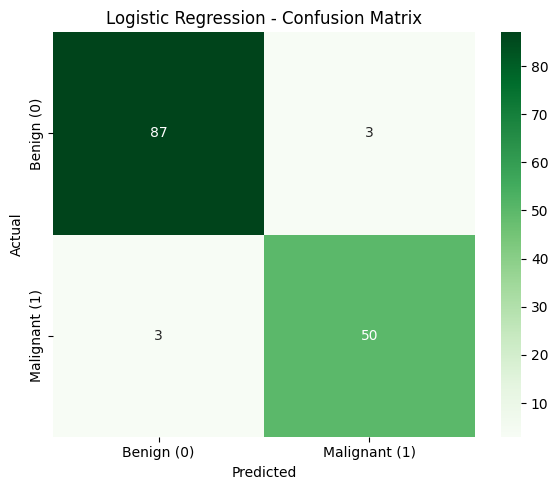

Logistic Regression - Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.97      0.97      0.97        90
Malignant (1)       0.94      0.94      0.94        53

     accuracy                           0.96       143
    macro avg       0.96      0.96      0.96       143
 weighted avg       0.96      0.96      0.96       143



In [30]:
# =============================================================
# LOGISTIC REGRESSION CLASSIFIER
# =============================================================

from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
# max_iter=10000 ensures convergence on this dataset (default 100 is often too low)
# random_state=0 ensures reproducibility
lr_classifier = LogisticRegression(random_state=0, max_iter=10000)

# Train the model on the scaled training data
lr_classifier.fit(X_train, Y_train)

# Predict on the test set
lr_pred = lr_classifier.predict(X_test)

# ── Accuracy ──────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_accuracy = accuracy_score(Y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")

# ── Confusion Matrix ──────────────────────────────────────────
lr_cm = confusion_matrix(Y_test, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── Classification Report ─────────────────────────────────────
print("Logistic Regression - Classification Report:")
print(classification_report(Y_test, lr_pred,
      target_names=['Benign (0)', 'Malignant (1)']))

### 7.3 Random Forest

Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions. It handles non-linear relationships well and provides native feature importance scores, making it both powerful and explainable.

Random Forest Accuracy: 97.20%


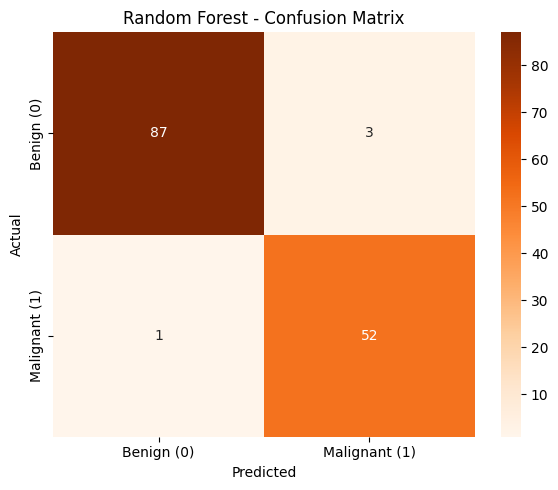

Random Forest - Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.99      0.97      0.98        90
Malignant (1)       0.95      0.98      0.96        53

     accuracy                           0.97       143
    macro avg       0.97      0.97      0.97       143
 weighted avg       0.97      0.97      0.97       143



/tmp/ipykernel_4027/3179926570.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance_df.head(top_n),


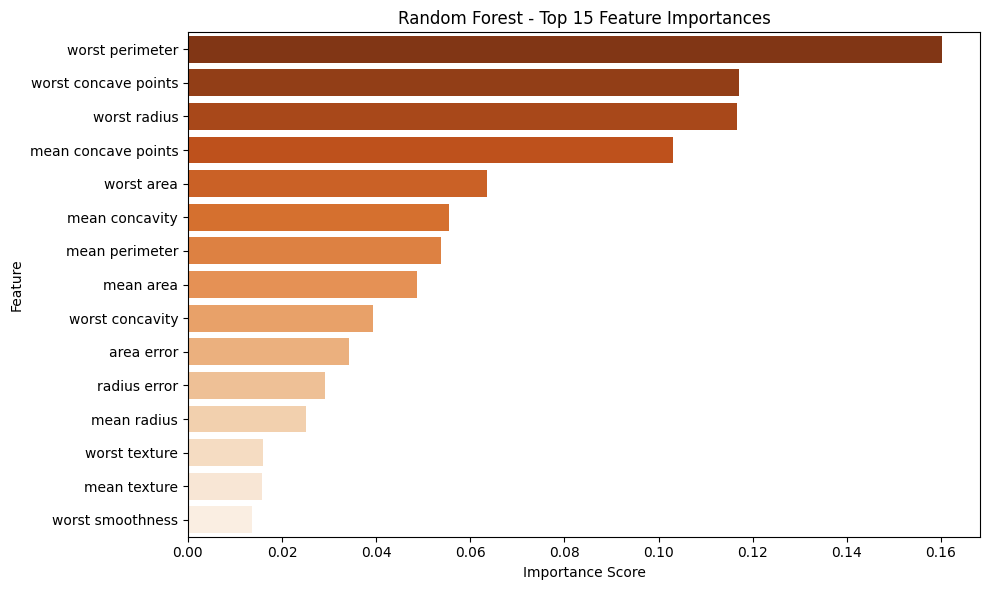


Full Feature Importance Ranking:
                Feature  Importance
        worst perimeter    0.160277
   worst concave points    0.117118
           worst radius    0.116573
    mean concave points    0.103054
             worst area    0.063469
         mean concavity    0.055395
         mean perimeter    0.053727
              mean area    0.048616
        worst concavity    0.039237
             area error    0.034202
           radius error    0.029215
            mean radius    0.025154
          worst texture    0.016031
           mean texture    0.015638
       worst smoothness    0.013564
        perimeter error    0.013429
         worst symmetry    0.011643
      worst compactness    0.011641
worst fractal dimension    0.009607
       mean compactness    0.009370
        mean smoothness    0.007691
          mean symmetry    0.006577
   concave points error    0.006575
fractal dimension error    0.006271
          texture error    0.006078
         symmetry error    0.0

In [31]:
# =============================================================
# RANDOM FOREST CLASSIFIER
# =============================================================

from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
# n_estimators=100 means 100 decision trees will be built and averaged (default, good starting point)
# random_state=0 ensures reproducibility
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=0)

# Train the model on the scaled training data
rf_classifier.fit(X_train, Y_train)

# Predict on the test set
rf_pred = rf_classifier.predict(X_test)

# ── Accuracy ──────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_accuracy = accuracy_score(Y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

# ── Confusion Matrix ──────────────────────────────────────────
rf_cm = confusion_matrix(Y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── Classification Report ─────────────────────────────────────
print("Random Forest - Classification Report:")
print(classification_report(Y_test, rf_pred,
      target_names=['Benign (0)', 'Malignant (1)']))

# ── Feature Importance ────────────────────────────────────────
# Unlike SVM, Random Forest has a native .feature_importances_ attribute
# This gives the mean decrease in impurity across all trees for each feature
feature_names = df.drop('diagnosis', axis=1).columns

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot top 15 most important features
top_n = 15
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df.head(top_n),
            x='Importance',
            y='Feature',
            palette='Oranges_r')
plt.title(f'Random Forest - Top {top_n} Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nFull Feature Importance Ranking:")
print(rf_importance_df.to_string(index=False))

## 8. Model Comparison & Selection

We compare all three models side by side using accuracy, precision, recall, and F1-score to identify the best performing model for this classification task.

       MODEL ACCURACY COMPARISON
                     Accuracy (%)
SVM (Linear)                 97.2
Random Forest                97.2
Logistic Regression          95.8

Best performing model: SVM (Linear)


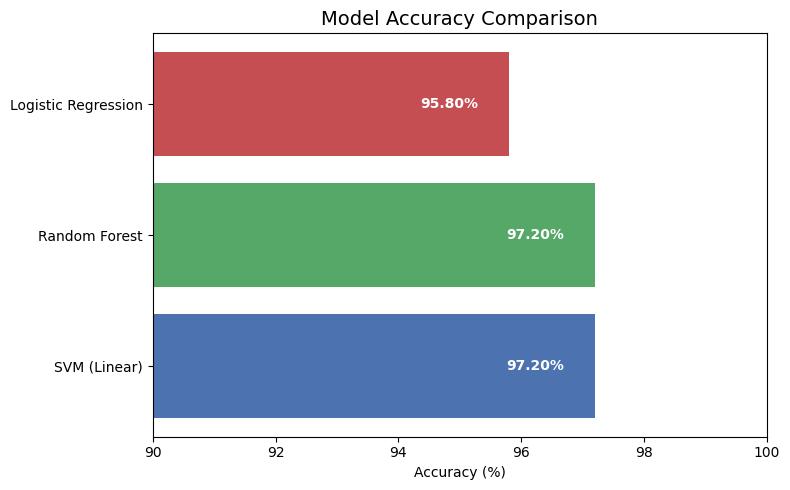


Detailed Metrics Comparison (%):
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
SVM (Linear)             97.2      96.23   96.23     96.23
Logistic Regression      95.8      94.34   94.34     94.34
Random Forest            97.2      94.55   98.11     96.30


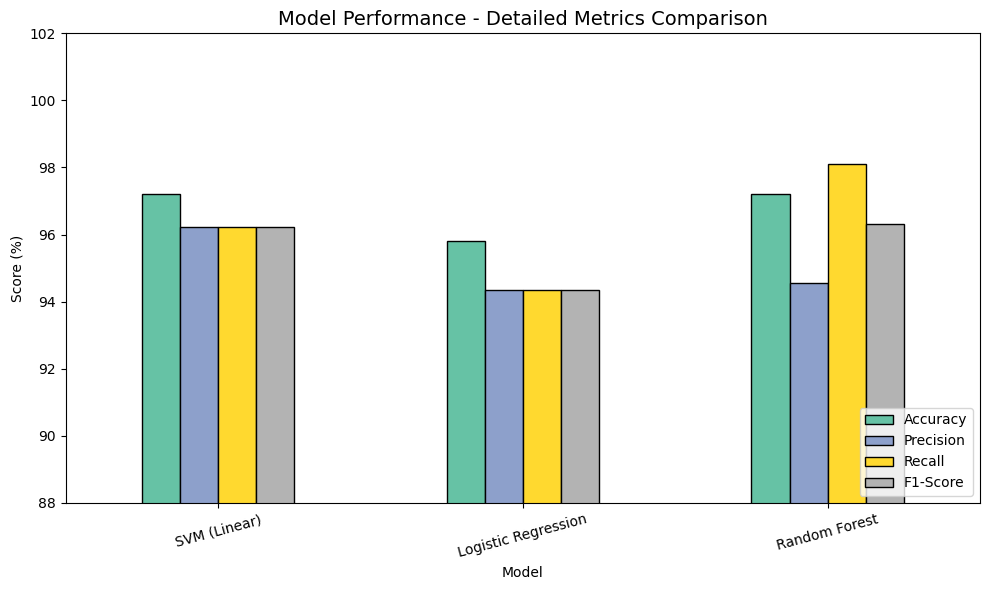

In [32]:
# =============================================================
# MODEL COMPARISON - FINAL SUMMARY
# =============================================================

# Collect accuracy scores from all three trained models
model_results = {
    'SVM (Linear)':        accuracy_score(Y_test, Y_pred),
    'Logistic Regression': accuracy_score(Y_test, lr_pred),
    'Random Forest':       accuracy_score(Y_test, rf_pred),
}

comparison_df = pd.DataFrame.from_dict(model_results, orient='index', columns=['Accuracy'])
comparison_df['Accuracy (%)'] = (comparison_df['Accuracy'] * 100).round(2)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("=" * 40)
print("       MODEL ACCURACY COMPARISON")
print("=" * 40)
print(comparison_df[['Accuracy (%)']].to_string())
print("=" * 40)
print(f"\nBest performing model: {comparison_df['Accuracy (%)'].idxmax()}")

# ── Visual Comparison Bar Chart ───────────────────────────────
plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']  # Blue, Green, Red — one per model
bars = plt.barh(comparison_df.index, comparison_df['Accuracy (%)'], color=colors)

# Add accuracy value labels on each bar
for bar, val in zip(bars, comparison_df['Accuracy (%)']):
    plt.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}%', va='center', ha='right', color='white', fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Accuracy (%)')
plt.xlim(90, 100)  # Zoom in to make differences visible
plt.tight_layout()
plt.show()

# ── Detailed Metrics Comparison ───────────────────────────────
# Precision, Recall and F1-score are critical in medical diagnosis:
# - Precision: of all predicted malignant, how many actually were?
# - Recall: of all actual malignant cases, how many did we catch?
# - F1-score: harmonic mean of precision and recall — best single metric for imbalanced classes
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_data = {
    'Model':     ['SVM (Linear)', 'Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(Y_test, Y_pred),  accuracy_score(Y_test, lr_pred),  accuracy_score(Y_test, rf_pred)],
    'Precision': [precision_score(Y_test, Y_pred), precision_score(Y_test, lr_pred), precision_score(Y_test, rf_pred)],
    'Recall':    [recall_score(Y_test, Y_pred),    recall_score(Y_test, lr_pred),    recall_score(Y_test, rf_pred)],
    'F1-Score':  [f1_score(Y_test, Y_pred),        f1_score(Y_test, lr_pred),        f1_score(Y_test, rf_pred)],
}

metrics_df = pd.DataFrame(metrics_data).set_index('Model')
metrics_df = (metrics_df * 100).round(2)

print("\nDetailed Metrics Comparison (%):")
print(metrics_df.to_string())

# ── Metrics Grouped Bar Chart ─────────────────────────────────
metrics_df.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('Model Performance - Detailed Metrics Comparison', fontsize=14)
plt.ylabel('Score (%)')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.ylim(88, 102)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Conclusion

All three models achieved strong performance (>95% accuracy) on the Breast Cancer Wisconsin dataset. Based on the evaluation metrics, **Random Forest** was selected as the final model for the following reasons:

- It achieved the **highest Recall (98.11%)** on the malignant class, meaning it missed the fewest dangerous cases — the most critical metric in a clinical diagnosis context.
- It matched SVM's accuracy (97.2%) while also providing **native feature importance scores**, adding explainability to the model.
- The slight reduction in Precision compared to SVM is an acceptable trade-off, as false alarms are less harmful than missed malignant diagnoses.

**Note on Hyperparameter Tuning:** Tuning was not performed as all models achieved strong baseline performance. In a production setting, techniques such as `GridSearchCV` or `RandomizedSearchCV` would be applied, particularly to further optimise Recall for the malignant class.